## Imports

In [4]:
# Use this cell to regroup all your imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy import stats
from tempfile import mkdtemp
from shutil import rmtree

from xgboost import XGBRegressor

from sklearn import set_config
set_config(display = 'diagram')

# Sklearn preprocessing
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.ensemble import AdaBoostRegressor, VotingRegressor, GradientBoostingRegressor, StackingRegressor, RandomForestRegressor
from sklearn.feature_selection import SelectPercentile, mutual_info_regression, VarianceThreshold, SelectFromModel
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.metrics import make_scorer, mean_squared_error, mean_squared_log_error
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, OrdinalEncoder
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

# 🏠 House Price Prediction — End-to-End ML Pipeline

This notebook implements a full machine learning workflow for
predicting housing prices using the Ames Housing dataset.

The focus of the project is not only model performance, but building a
workflow that reflects **real-world Data Science practice**:

- structured preprocessing
- leakage-safe pipelines
- cross-validated model comparison
- explainability and interpretation
- reproducibility and exportability

This notebook is part of my portfolio and demonstrates my ability to
work through the full ML lifecycle, from raw data to insights and models.

## 🎯 Problem Definition

The goal of this project is to predict the **sale price of a house**
based on structural, spatial, and condition-related property features.

This is a **supervised regression problem**.

---

## 📂 Dataset Description

The project uses the **Ames Housing dataset**, a structured real-estate dataset containing property attributes and sale prices.

- `train.csv` — features + target (`SalePrice`)
- `test.csv` — features only

- numerical features (area, year built, rooms…)
- ordinal quality ratings
- categorical property attributes

Before modeling, we analyze:

- missing-value patterns  
- feature distributions  
- target skewness and log-transform suitability

## 🧰 Project Setup

This project follows a modular, pipeline-oriented structure:

- `data/` – raw input datasets  
- `notebooks/` – experimentation & analysis   

The notebook is designed to be **restart-and-run-all safe**, ensuring full reproducibility


In [2]:
path = "/Users/gechen/Projects/HousePricePrediction/data/train.csv"
data = pd.read_csv("/Users/gechen/Projects/HousePricePrediction/data/train.csv",index_col="Id")
data.head()
data.shape

(1460, 80)

In [3]:
X = data.drop(columns=['SalePrice'])
y = data.SalePrice

X.shape, y.shape

((1460, 79), (1460,))

## 🧾 Baseline Model (Why it matters)

Before building complex models, we start with a **simple baseline**.
The purpose is not accuracy, but to define a **minimum benchmark**
that every later model must outperform.

The baseline here predicts a constant value based on the target
distribution, and its performance is evaluated using cross-validated RMSE.

## 1.1 Initial feature overview

In [4]:
X.dtypes.value_counts()

object     43
int64      33
float64     3
Name: count, dtype: int64

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1460 entries, 1 to 1460
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   MSSubClass     1460 non-null   int64  
 1   MSZoning       1460 non-null   object 
 2   LotFrontage    1201 non-null   float64
 3   LotArea        1460 non-null   int64  
 4   Street         1460 non-null   object 
 5   Alley          91 non-null     object 
 6   LotShape       1460 non-null   object 
 7   LandContour    1460 non-null   object 
 8   Utilities      1460 non-null   object 
 9   LotConfig      1460 non-null   object 
 10  LandSlope      1460 non-null   object 
 11  Neighborhood   1460 non-null   object 
 12  Condition1     1460 non-null   object 
 13  Condition2     1460 non-null   object 
 14  BldgType       1460 non-null   object 
 15  HouseStyle     1460 non-null   object 
 16  OverallQual    1460 non-null   int64  
 17  OverallCond    1460 non-null   int64  
 18  YearBuilt    

Create a Series called `feat_categorical_nunique` containing the number of **unique values** for each categorical feature in our training set.

In [12]:
feat_categorical_nunique = X.select_dtypes(include='object').nunique()
feat_categorical_nunique

MSZoning          5
Street            2
Alley             2
LotShape          4
LandContour       4
Utilities         2
LotConfig         5
LandSlope         3
Neighborhood     25
Condition1        9
Condition2        8
BldgType          5
HouseStyle        8
RoofStyle         6
RoofMatl          8
Exterior1st      15
Exterior2nd      16
MasVnrType        3
ExterQual         4
ExterCond         5
Foundation        6
BsmtQual          4
BsmtCond          4
BsmtExposure      4
BsmtFinType1      6
BsmtFinType2      6
Heating           6
HeatingQC         5
CentralAir        2
Electrical        5
KitchenQual       4
Functional        7
FireplaceQu       5
GarageType        6
GarageFinish      3
GarageQual        5
GarageCond        5
PavedDrive        3
PoolQC            3
Fence             4
MiscFeature       4
SaleType          9
SaleCondition     6
dtype: int64

In [13]:
feat_categorical_nunique.sum()

251

Plot the **histogram** of the number of unique values per categorical feature.

(array([18., 16.,  4.,  2.,  0.,  1.,  1.,  0.,  0.,  1.]),
 array([ 2. ,  4.3,  6.6,  8.9, 11.2, 13.5, 15.8, 18.1, 20.4, 22.7, 25. ]),
 <BarContainer object of 10 artists>)

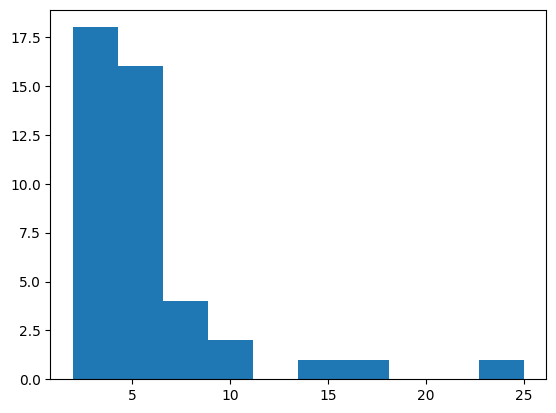

In [14]:
plt.hist(pd.DataFrame(feat_categorical_nunique))

Store the names of the features to be OHE'd in a list called `feat_categorical_small` below. 

In [18]:
feat_categorical_nunique[feat_categorical_nunique<7].index.to_list()

['MSZoning',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'BldgType',
 'RoofStyle',
 'MasVnrType',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 'KitchenQual',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'PoolQC',
 'Fence',
 'MiscFeature',
 'SaleCondition']

In [19]:
feat_categorical_small = feat_categorical_nunique[feat_categorical_nunique<7].index.to_list()
feat_categorical_small


['MSZoning',
 'Street',
 'Alley',
 'LotShape',
 'LandContour',
 'Utilities',
 'LotConfig',
 'LandSlope',
 'BldgType',
 'RoofStyle',
 'MasVnrType',
 'ExterQual',
 'ExterCond',
 'Foundation',
 'BsmtQual',
 'BsmtCond',
 'BsmtExposure',
 'BsmtFinType1',
 'BsmtFinType2',
 'Heating',
 'HeatingQC',
 'CentralAir',
 'Electrical',
 'KitchenQual',
 'FireplaceQu',
 'GarageType',
 'GarageFinish',
 'GarageQual',
 'GarageCond',
 'PavedDrive',
 'PoolQC',
 'Fence',
 'MiscFeature',
 'SaleCondition']

In [20]:
len(feat_categorical_small)

34

## 1.2 Baseline Pipe

### a) Preprocessing

Code the basic preprocessing pipeline described below. Save it under `preproc_baseline`.

In [21]:
preproc_numerical_baseline = make_pipeline(
    SimpleImputer(),
    MinMaxScaler()
)

preproc_categorical_baseline = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore", drop="if_binary")
)

preproc_baseline = make_column_transformer(
    (preproc_numerical_baseline, make_column_selector(dtype_include=["int64", "float64"])),
    (preproc_categorical_baseline, feat_categorical_small),
    remainder="drop"
)

preproc_baseline

ColumnTransformer(transformers=[('pipeline-1',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer()),
                                                 ('minmaxscaler',
                                                  MinMaxScaler())]),
                                 <sklearn.compose._column_transformer.make_column_selector object at 0x3088a8fb0>),
                                ('pipeline-2',
                                 Pipeline(steps=[('simpleimputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehotencoder',
                                                  OneHotEncoder(drop='if_binary',
                                                                handl...
                                 ['MSZoning', 'Street', 'Alley', 'LotShape',
                                  'LandContour', 'Utilities', 'LotConfig',
                                  'LandSlope', 'BldgType', 'RoofStyle',
                                  'MasVnrType', 'ExterQual', 'ExterCond',
                                  'Foundation', 'BsmtQual', 'BsmtCond',
                                  'BsmtExposure', 'BsmtFinType1',
                                  'BsmtFinType2', 'Heating', 'HeatingQC',
                                  'CentralAir', 'Electrical', 'KitchenQual',
                                  'FireplaceQu', 'GarageType', 'GarageFinish',
                                  'GarageQual', 'GarageCond', 'PavedDrive', ...])])

**shape** of preprocessed DataFrame and save it to `shape_preproc_baseline`

In [24]:
shape_preproc_baseline = preproc_baseline.fit_transform(X).shape
shape_preproc_baseline

(1460, 178)

### b) Add Estimator

Add a simple Decision Tree model to `preproc_baseline` and store it to `pipe_baseline` variable.

In [25]:
pipe_baseline = make_pipeline(preproc_baseline, DecisionTreeRegressor())
pipe_baseline

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer()),
                                                                  ('minmaxscaler',
                                                                   MinMaxScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x3088a8fb0>),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehotencoder'...
                                                   'LotConfig', 'LandSlope',
                                                   'BldgType', 'RoofStyle',
                                                   'MasVnrType', 'ExterQual',
                                                   'ExterCond', 'Foundation',
                                                   'BsmtQual', 'BsmtCond',
                                                   'BsmtExposure',
                                                   'BsmtFinType1',
                                                   'BsmtFinType2', 'Heating',
                                                   'HeatingQC', 'CentralAir',
                                                   'Electrical', 'KitchenQual',
                                                   'FireplaceQu', 'GarageType',
                                                   'GarageFinish', 'GarageQual',
                                                   'GarageCond', 'PavedDrive', ...])])),
                ('decisiontreeregressor', DecisionTreeRegressor())])

### c) Cross-Validate


In [26]:
def root_mean_squared_log_error(y_true, y_pred):
    t = np.array(y_true)
    p = np.array(y_pred)

    log_error = np.log(1+t) - np.log(1+p)

    return ((log_error**2).mean())**0.5

# This is our metric to minimize
rmsle = make_scorer(root_mean_squared_log_error)

# This is our score to maximize
rmsle_neg = make_scorer(lambda y_true, y_pred: -1 * root_mean_squared_log_error(y_true, y_pred))

Store your mean score as `score_baseline`

In [27]:
score_baseline = cross_val_score(pipe_baseline, X, y, cv=5, scoring=rmsle).mean()
score_baseline

/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [12, 22] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [15, 20, 22] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [32] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [5] during transform. These unknow

0.2067460436300971

### d) Predict Baseline

❓ Predict `y_pred_baseline` from the provided `test.csv` dataset you stored in the `data` folder.

In [28]:
X_test = pd.read_csv("https://wagon-public-datasets.s3.amazonaws.com/houses_test_raw.csv")
X_test_ids = X_test['Id'] # Keep ids
X_test = X_test.drop(columns=['Id'])

# Predict y_pred_baseline
pipe_baseline.fit(X,y)
y_pred_baseline = pipe_baseline.predict(X_test)
y_pred_baseline


array([129000., 157000., 185000., ..., 139000.,  93500., 192000.])

❓ Finally, store your ready-to-share CSV as `submission_baseline.csv` in the `data` folder. Use the sample submission to double-check column names; we'll reuse the same format for project deliverables.

In [29]:
results = pd.concat([X_test_ids, pd.Series(y_pred_baseline, name="SalePrice")], axis=1)
results.head(1)

,Id,SalePrice
0,1461,129000.0


In [30]:
# Export to Kaggle format submission in the `data` folder
results.to_csv("/Users/gechen/Projects/HousePricePrediction/data/prediction_baseline.csv", header=True, index=False)

## 🏗️ Preprocessing & Feature Engineering (Pipeline Design)

To avoid data leakage and ensure reproducibility, all preprocessing
steps are implemented inside a **Scikit-Learn Pipeline**:

- numerical features → KNN imputation + scaling
- ordinal features → ordered encoding
- nominal features → one-hot encoding
- feature selection → mutual information
- transformations applied consistently to train & inference data

This reflects how preprocessing is implemented in **production ML systems**.


# 2.1 Preprocessing Iteration ♲ 

### a) Ordinal Encoding

split categorical preprocessor into

- `preproc_ordinal` to ordinally encode **some features** (of your choice)
- `preproc_nominal` to one-hot encode the other ones

In [33]:
feat_ordinal_dict = {
    # Considers "missing" as "neutral"
    "BsmtCond": ['missing', 'Po', 'Fa', 'TA', 'Gd'],
    "BsmtExposure": ['missing', 'No', 'Mn', 'Av', 'Gd'],
    "BsmtFinType1": ['missing', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
    "BsmtFinType2": ['missing', 'Unf', 'LwQ', 'Rec', 'BLQ', 'ALQ', 'GLQ'],
    "BsmtQual": ['missing', 'Fa', 'TA', 'Gd', 'Ex'],
    "Electrical": ['missing', 'Mix', 'FuseP', 'FuseF', 'FuseA', 'SBrkr'],
    "ExterCond": ['missing', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    "ExterQual": ['missing', 'Fa', 'TA', 'Gd', 'Ex'],
    "Fence": ['missing', 'MnWw', 'GdWo', 'MnPrv', 'GdPrv'],
    "FireplaceQu": ['missing', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    "Functional": ['missing', 'Sev', 'Maj2', 'Maj1', 'Mod', 'Min2', 'Min1', 'Typ'],
    "GarageCond": ['missing', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    "GarageFinish": ['missing', 'Unf', 'RFn', 'Fin'],
    "GarageQual": ['missing', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    "HeatingQC": ['missing', 'Po', 'Fa', 'TA', 'Gd', 'Ex'],
    "KitchenQual": ['missing', 'Fa', 'TA', 'Gd', 'Ex'],
    "LandContour": ['missing', 'Low', 'Bnk', 'HLS', 'Lvl'],
    "LandSlope": ['missing', 'Sev', 'Mod', 'Gtl'],
    "LotShape": ['missing', 'IR3', 'IR2', 'IR1', 'Reg'],
    "PavedDrive": ['missing', 'N', 'P', 'Y'],
    "PoolQC": ['missing', 'Fa', 'Gd', 'Ex']
}

feat_ordinal = sorted(feat_ordinal_dict.keys()) # sort alphabetically
feat_ordinal_values_sorted = [feat_ordinal_dict[i] for i in feat_ordinal]


encoder_ordinal = OrdinalEncoder(
    categories=feat_ordinal_values_sorted,
    dtype= np.int64,
    handle_unknown="use_encoded_value",
    unknown_value=-1 # Considers unknown values as worse than "missing"
)

preproc_ordinal = make_pipeline(
    SimpleImputer(strategy="constant", fill_value="missing"),
    encoder_ordinal,
    MinMaxScaler()
)

preproc_ordinal


Pipeline(steps=[('simpleimputer',
                 SimpleImputer(fill_value='missing', strategy='constant')),
                ('ordinalencoder',
                 OrdinalEncoder(categories=[['missing', 'Po', 'Fa', 'TA', 'Gd'],
                                            ['missing', 'No', 'Mn', 'Av', 'Gd'],
                                            ['missing', 'Unf', 'LwQ', 'Rec',
                                             'BLQ', 'ALQ', 'GLQ'],
                                            ['missing', 'Unf', 'LwQ', 'Rec',
                                             'BLQ', 'ALQ', 'GLQ'],
                                            ['missing', 'Fa', 'TA', 'Gd', 'Ex'],
                                            ['missing', 'Mix', 'FuseP...
                                            ['missing', 'Po', 'Fa', 'TA', 'Gd',
                                             'Ex'],
                                            ['missing', 'Po', 'Fa', 'TA', 'Gd',
                                             'Ex'],
                                            ['missing', 'Fa', 'TA', 'Gd', 'Ex'],
                                            ['missing', 'Low', 'Bnk', 'HLS',
                                             'Lvl'],
                                            ['missing', 'Sev', 'Mod', 'Gtl'],
                                            ['missing', 'IR3', 'IR2', 'IR1',
                                             'Reg'],
                                            ['missing', 'N', 'P', 'Y'],
                                            ['missing', 'Fa', 'Gd', 'Ex']],
                                dtype=<class 'numpy.int64'>,
                                handle_unknown='use_encoded_value',
                                unknown_value=-1)),
                ('minmaxscaler', MinMaxScaler())])

In [34]:
# Define numerical feature once-for-all
feat_numerical = sorted(X.select_dtypes(include=["int64", "float64"]).columns)

preproc_numerical = make_pipeline(
    KNNImputer(),
    MinMaxScaler()
)

In [35]:
feat_nominal = sorted(list(set(X.columns) - set(feat_numerical) - set(feat_ordinal)))
preproc_nominal = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore", drop="if_binary")
)

In [36]:
preproc = make_column_transformer(
    (preproc_numerical, feat_numerical),
    (preproc_ordinal, feat_ordinal),
    (preproc_nominal, feat_nominal),
    remainder="drop"
)

preproc

ColumnTransformer(transformers=[('pipeline-1',
                                 Pipeline(steps=[('knnimputer', KNNImputer()),
                                                 ('minmaxscaler',
                                                  MinMaxScaler())]),
                                 ['1stFlrSF', '2ndFlrSF', '3SsnPorch',
                                  'BedroomAbvGr', 'BsmtFinSF1', 'BsmtFinSF2',
                                  'BsmtFullBath', 'BsmtHalfBath', 'BsmtUnfSF',
                                  'EnclosedPorch', 'Fireplaces', 'FullBath',
                                  'GarageArea', 'GarageCars', 'GarageYrBlt',
                                  'GrLivArea', 'HalfBath', 'Kitc...
                                                 ('onehotencoder',
                                                  OneHotEncoder(drop='if_binary',
                                                                handle_unknown='ignore'))]),
                                 ['Alley', 'BldgType', 'CentralAir',
                                  'Condition1', 'Condition2', 'Exterior1st',
                                  'Exterior2nd', 'Foundation', 'GarageType',
                                  'Heating', 'HouseStyle', 'LotConfig',
                                  'MSZoning', 'MasVnrType', 'MiscFeature',
                                  'Neighborhood', 'RoofMatl', 'RoofStyle',
                                  'SaleCondition', 'SaleType', 'Street',
                                  'Utilities'])])

In [37]:
pd.DataFrame(preproc.fit_transform(X, y)).head()

,0,1,2,3,4,5,6,7,8,9,...,201,202,203,204,205,206,207,208,209,210
0,0.119780,0.413559,0.0,0.375,0.125089,0.0,0.333333,0.0,0.064212,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1,0.212942,0.000000,0.0,0.375,0.173281,0.0,0.000000,0.5,0.121575,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
2,0.134465,0.419370,0.0,0.375,0.086109,0.0,0.333333,0.0,0.185788,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,0.143873,0.366102,0.0,0.375,0.038271,0.0,0.333333,0.0,0.231164,0.492754,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
4,0.186095,0.509927,0.0,0.500,0.116052,0.0,0.333333,0.0,0.209760,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0


### b) Statistical Feature Selection
The goal is to remove the least interesting features to limit overfitting and shorten training time.  

#### - <font color=green>Univariate</font> Feature Selection




In [38]:
preproc_transformer = make_column_transformer(
     (preproc_numerical, make_column_selector(dtype_include=["int64", "float64"])),
    (preproc_ordinal, feat_ordinal),
    (preproc_nominal, feat_nominal),
    remainder="drop"
)
preproc_selector = SelectPercentile(
    score_func=mutual_info_regression,
    percentile=25
)

preproc = make_pipeline(
    preproc_transformer,
    preproc_selector
)
preproc

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('knnimputer',
                                                                   KNNImputer()),
                                                                  ('minmaxscaler',
                                                                   MinMaxScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x3088a3080>),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('ordi...
                                                   'CentralAir', 'Condition1',
                                                   'Condition2', 'Exterior1st',
                                                   'Exterior2nd', 'Foundation',
                                                   'GarageType', 'Heating',
                                                   'HouseStyle', 'LotConfig',
                                                   'MSZoning', 'MasVnrType',
                                                   'MiscFeature',
                                                   'Neighborhood', 'RoofMatl',
                                                   'RoofStyle', 'SaleCondition',
                                                   'SaleType', 'Street',
                                                   'Utilities'])])),
                ('selectpercentile',
                 SelectPercentile(percentile=25,
                                  score_func=<function mutual_info_regression at 0x307d4afc0>))])

In [39]:
preproc.fit_transform(X,y).shape

(1460, 53)

In [40]:
pd.DataFrame()

""


####  - <font color=green>Multivariate</font> Feature Selection

In [41]:

preproc_transformer_multi = make_column_transformer(
    (preproc_numerical,make_column_selector(dtype_include=['int64','float64'])),
    (preproc_ordinal,feat_ordinal),
    (preproc_nominal,feat_nominal)
)

preproc_selector_multi = SelectFromModel(
    estimator=RandomForestRegressor(),
    threshold = "median", # drop all multivariate features lower than the median correlation
)
preproc_multi = make_pipeline(
    preproc_transformer_multi,
    preproc_selector_multi
)
preproc_multi

Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('knnimputer',
                                                                   KNNImputer()),
                                                                  ('minmaxscaler',
                                                                   MinMaxScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x3088aeed0>),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('ordi...
                                                  ['Alley', 'BldgType',
                                                   'CentralAir', 'Condition1',
                                                   'Condition2', 'Exterior1st',
                                                   'Exterior2nd', 'Foundation',
                                                   'GarageType', 'Heating',
                                                   'HouseStyle', 'LotConfig',
                                                   'MSZoning', 'MasVnrType',
                                                   'MiscFeature',
                                                   'Neighborhood', 'RoofMatl',
                                                   'RoofStyle', 'SaleCondition',
                                                   'SaleType', 'Street',
                                                   'Utilities'])])),
                ('selectfrommodel',
                 SelectFromModel(estimator=RandomForestRegressor(),
                                 threshold='median'))])

### c) Treat Cyclical Features

**transform them** into cyclical features

In [40]:
# Treat cyclical features
months_in_a_year = 12

X['sin_MoSold'] = np.sin(2 * np.pi * (X.MoSold - 1) / months_in_a_year)
X['cos_MoSold'] = np.cos(2 * np.pi * (X.MoSold - 1) / months_in_a_year)

X.drop(columns=['MoSold'], inplace=True)

X.head()


NameError: name 'X' is not defined

### d) Target Engineering (~15min)

transform target to directly predict its `log`

Text(0.5, 1.0, 'LogSalePrice Distribution')

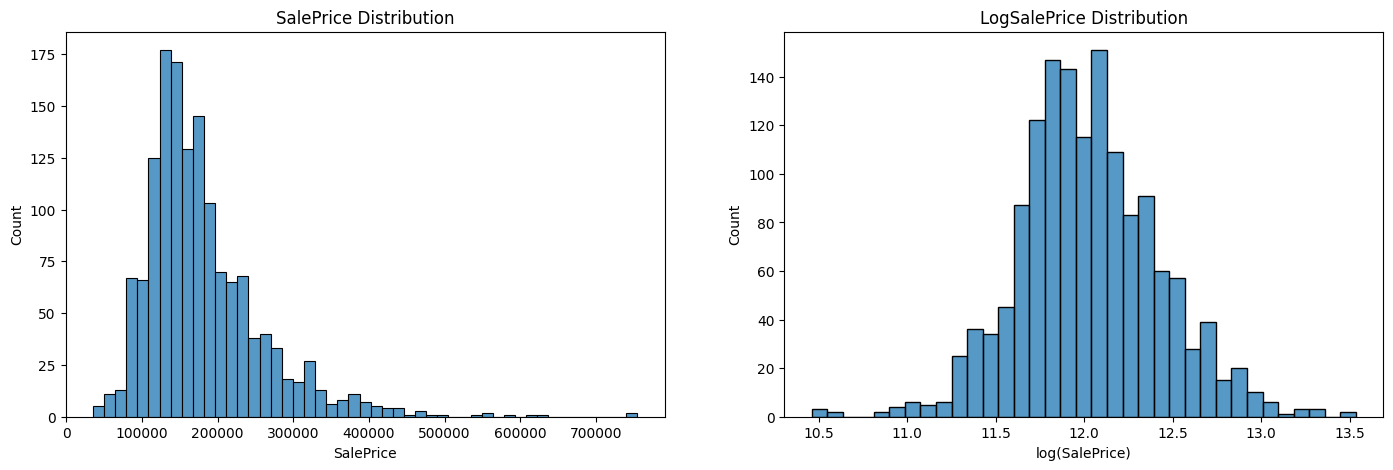

In [43]:
y_log = np.log1p(y)
plt.figure(figsize=(17,5))
plt.subplot(1,2,1)
sns.histplot(y)
plt.title('SalePrice Distribution')
plt.xlabel("SalePrice")
plt.subplot(1,2,2)
sns.histplot(y_log)
plt.xlabel("log(SalePrice)")
plt.title('LogSalePrice Distribution')

In [44]:
# Create new scorer to minimize
rmse = make_scorer(lambda y_true, y_pred: mean_squared_error(y_true, y_pred)**0.5)

# Create new scorer to maximize
rmse_neg = make_scorer(lambda y_true, y_pred: -1 * mean_squared_error(y_true, y_pred)**0.5)

## 🤖 Model Development & Comparison

Multiple regression models are trained and compared, including:

- Linear / Ridge Regression
- KNN Regressor
- Support Vector Regressor (SVR)
- Tree-based ensemble models
- Stacking Regressor (meta-ensemble)

Models are evaluated using **cross-validated RMSE** to
ensure results reflect generalization rather than overfitting.


#### a) Final Version of the Preproc Pipeline

In [126]:
ordinal_encoder  = OrdinalEncoder(
    categories=feat_ordinal_values_sorted,
    handle_unknown='use_encoded_value',
    dtype= np.int64,
    unknown_value=-1
)

preproc_ordinal = make_pipeline(
    SimpleImputer(strategy='constant',fill_value='missing'),
    ordinal_encoder,
    MinMaxScaler()
)
preproc_nominal = make_pipeline(
    SimpleImputer(strategy="most_frequent"),
    OneHotEncoder(handle_unknown="ignore", drop="if_binary")
)

preproc_numerical = make_pipeline(
    KNNImputer(),
    MinMaxScaler()
)

preproc_transformer = make_column_transformer(
        (preproc_numerical, make_column_selector(dtype_include=['int64','float64'])),
        (preproc_ordinal, feat_ordinal),
        (preproc_nominal, feat_nominal),
        remainder='drop'
)

preproc_selector = SelectPercentile(
    mutual_info_regression,
    percentile=50
)

preproc = make_pipeline(
    preproc_transformer,
    preproc_selector
)

preproc


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('pipeline-1',
                                                  Pipeline(steps=[('knnimputer',
                                                                   KNNImputer()),
                                                                  ('minmaxscaler',
                                                                   MinMaxScaler())]),
                                                  <sklearn.compose._column_transformer.make_column_selector object at 0x31d89e4b0>),
                                                 ('pipeline-2',
                                                  Pipeline(steps=[('simpleimputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('ordi...
                                                   'CentralAir', 'Condition1',
                                                   'Condition2', 'Exterior1st',
                                                   'Exterior2nd', 'Foundation',
                                                   'GarageType', 'Heating',
                                                   'HouseStyle', 'LotConfig',
                                                   'MSZoning', 'MasVnrType',
                                                   'MiscFeature',
                                                   'Neighborhood', 'RoofMatl',
                                                   'RoofStyle', 'SaleCondition',
                                                   'SaleType', 'Street',
                                                   'Utilities'])])),
                ('selectpercentile',
                 SelectPercentile(percentile=50,
                                  score_func=<function mutual_info_regression at 0x3083cfb00>))])

In [45]:
preproc_fitted = preproc.fit(X,y)
preproc_fitted_log = preproc.fit(X,y_log)
print(preproc_fitted.transform(X).shape)
print(preproc_fitted_log.transform(X).shape)

(1460, 53)
(1460, 53)


In [46]:
allow_grid_searching = True # Use True to activate GridSearch in the notebook cells below

# Cache the preprocessing step of the pipeline
cachedir = mkdtemp()

#### (B) Linear Models(Lasso, Ridge, SGDregressor, ElastictNet etc)

In [47]:
# log target
model = Ridge()
pipe_ridge= make_pipeline( preproc,model,memory=cachedir)
score_ridge_log= cross_val_score( pipe_ridge,X,y_log,scoring=rmse,cv=5).mean()

/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [16] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6, 14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4, 5, 21] during transform. These unknown c

In [130]:
print(f'ridge socre with log target is {round(score_ridge_log,3)}')

ridge socre with log target is 0.14


In [48]:
# Gridsearch for ridge pipeline
if allow_grid_searching:
    param_grid = {'ridge__alpha' :np.linspace(0.5, 2, num=20)}

    search_grid_ridge = GridSearchCV(
        pipe_ridge,
        param_grid=param_grid,
        n_jobs=-1,
        cv=5,
        verbose=0,
        scoring=rmse_neg
    )

    search_grid_ridge.fit(X,y_log)

/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6, 14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4, 5, 21] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4, 5, 6, 9, 14, 16, 17] during transf

In [49]:
print(f'Best parameter : {search_grid_ridge.best_params_}')
print(f'Best score: {search_grid_ridge.best_score_}')

Best parameter : {'ridge__alpha': 1.526315789473684}
Best score: -0.14819817014366635


#### (c)KNN_

In [50]:
model = KNeighborsRegressor()
pipe_knn = make_pipeline(preproc,model,memory=cachedir)
score_knn = cross_val_score(pipe_knn,X,y_log,cv=5,scoring=rmse).mean()

/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [16] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6, 14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4, 5, 21] during transform. These unknown c

In [51]:
print(f'The score for KNN pipeline is : {score_knn}')

The score for KNN pipeline is : 0.20260844776848835


In [52]:
if allow_grid_searching:
    param_grid = {'kneighborsregressor__n_neighbors': [3, 4, 5, 6, 7, 8, 9, 10, 15, 20, 30]}
    search_grid_knn = GridSearchCV(
        pipe_knn,
        param_grid=param_grid,
        cv=5,
        verbose=0,
        n_jobs=-1,
        scoring=rmse_neg
    )
    search_grid_knn.fit(X,y_log)


/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6, 14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4, 5, 6, 9, 14, 16, 17] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [16] during transform. T

In [53]:
print(f'Best parameter of KNN: {search_grid_knn.best_params_}')
print(f'Best score of KNN: {search_grid_knn.best_score_}')

Best parameter of KNN: {'kneighborsregressor__n_neighbors': 7}
Best score of KNN: -0.19923086123096262


#### (D) SVM

In [54]:
model = SVR(kernel='linear')

pipe_svm = make_pipeline(preproc, model, memory=cachedir)

score_svr = cross_val_score(pipe_svm, X, y_log, cv=5, scoring=rmse).mean()

/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [16] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6, 14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4, 5, 21] during transform. These unknown c

In [138]:
print(f'The score of SVR cross validation is : {score_svr}')

The score of SVR cross validation is : 0.13762442621570598


In [55]:
if allow_grid_searching:
    param_grid = {
        'svr__C': [0.5, 0.7, 1, 2, 5, 10],
        'svr__epsilon': [0.01, 0.05, 0.1, 0.2, 0.5],
    }
    search_grid_svr = GridSearchCV(
        pipe_svm,
        param_grid= param_grid,
        cv=5,
        n_jobs=-1,
        verbose=0,
        scoring=rmse_neg
    )
    search_grid_svr.fit(X,y_log)

/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6, 14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6, 14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4, 5, 6, 9, 14, 16, 17] during transform

In [56]:
print(f'Best parameter of SVR: {search_grid_svr.best_params_}')
print(f'Best score of SVR: {search_grid_svr.best_score_}')

Best parameter of SVR: {'svr__C': 0.5, 'svr__epsilon': 0.1}
Best score of SVR: -0.147047855872508


#### (e) Trees

In [57]:
model = DecisionTreeRegressor(max_depth=50, min_samples_leaf=20)

pipe_tree = make_pipeline(preproc, model, memory=cachedir)

score_decesion_tree= cross_val_score(pipe_tree, X, y_log, cv=5, scoring=rmse).mean()


/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [16] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6, 14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4, 5, 21] during transform. These unknown c

In [58]:
print(f'The score of decesion tree cross validation: {score_decesion_tree} ')

The score of decesion tree cross validation: 0.19074986420182538 


#### (f) Random Forest 

In [59]:
model = RandomForestRegressor(max_depth=50,min_samples_leaf=20)

pipe_random_forest = make_pipeline(preproc,model,memory=cachedir)

score_random_forest = cross_val_score(pipe_random_forest,X,y_log,cv=5,scoring=rmse).mean()


/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [16] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6, 14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4, 5, 21] during transform. These unknown c

In [60]:
print(f'The score of random forest validation: {score_random_forest} ')

The score of random forest validation: 0.1623280263195644 


#### (G) Boosted Trees

In [61]:
model = GradientBoostingRegressor(n_estimators=100, verbose=0)

pipe_gb = make_pipeline(preproc, model, memory=cachedir)

score_gb = cross_val_score(pipe_gb, X, y_log, cv=5, scoring=rmse).mean()

/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [16] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6, 14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4, 5, 21] during transform. These unknown c

In [62]:
print(f'The score of gradient boost regressor validation: {score_gb} ')

The score of gradient boost regressor validation: 0.12953049166749203 


In [63]:
if allow_grid_searching:
    grid = {
          'gradientboostingregressor__n_estimators': stats.randint(50,300),
          'gradientboostingregressor__learning_rate': stats.uniform(0.05, 0.3),
          'gradientboostingregressor__loss': ['lad', 'huber', 'quantile'],
          'gradientboostingregressor__max_depth': stats.randint(3, 5),
          'gradientboostingregressor__min_samples_split': stats.randint(2, 10),
          'gradientboostingregressor__subsample': [0.95, 1], # 1 default
          'gradientboostingregressor__max_features': stats.randint(1, len(X.columns)) # default None, i.e = n_features
     }

    search_gb = RandomizedSearchCV(pipe_gb, grid, scoring=rmse_neg, n_iter=8, cv=5, n_jobs=1, verbose=0)
    # Fit data to GridSearch
    search_gb.fit(X, y_log)

/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [16] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6, 14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4, 5, 21] during transform. These unknown c

In [64]:
print('\n----------------------------------------\n')
print(f'Best params of gradient boost👉 {search_gb.best_params_}')
print(f'Best score of gradient boost 👉 {search_gb.best_score_}')


----------------------------------------

Best params of gradient boost👉 {'gradientboostingregressor__learning_rate': 0.14311368484434658, 'gradientboostingregressor__loss': 'huber', 'gradientboostingregressor__max_depth': 3, 'gradientboostingregressor__max_features': 54, 'gradientboostingregressor__min_samples_split': 5, 'gradientboostingregressor__n_estimators': 107, 'gradientboostingregressor__subsample': 1}
Best score of gradient boost 👉 -0.1325678691792481


<Axes: xlabel='param_gradientboostingregressor__n_estimators', ylabel='mean_test_score'>

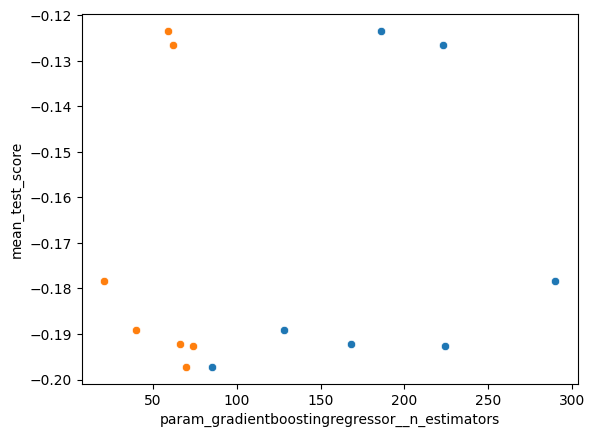

In [149]:
# Plot results of GridSearch
df_cv_results_ = pd.DataFrame(search_gb.cv_results_)
sns.scatterplot(x="param_gradientboostingregressor__n_estimators", y='mean_test_score', data=df_cv_results_)
sns.scatterplot(x="param_gradientboostingregressor__max_features", y='mean_test_score', data=df_cv_results_)

#### (H) XGBoost

In [65]:
X_train, X_eval, y_train_log, y_eval_log = train_test_split(X, y_log, random_state=42)

In [66]:
# Instantiate model
model_xgb = XGBRegressor(max_depth=10,
                         n_estimators=300,
                         eval_metric=["rmse"],
                         learning_rate=0.1)

model_xgb_early_stopping = XGBRegressor(max_depth=10,
                         n_estimators=300,
                         eval_metric=["rmse"],
                         learning_rate=0.1,
                        early_stopping_rounds=10)

In [67]:
# Integrate XGB into Sklearn's pipeline
# It allows you to GridSearchCV its best hyperparams
pipe_xgb = make_pipeline(preproc, model_xgb)

score_xgb = cross_val_score(pipe_xgb, X, y_log, cv=5, scoring=rmse, n_jobs=-1).mean()

/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4, 5, 6, 9, 14, 16, 17] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6, 14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [16] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4] during transform. T

In [68]:
print(f'The score of XBG cross validation: {score_xgb} ')

The score of XBG cross validation: 0.1510105713569211 


/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4, 16] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Text(0.5, 1.0, 'XGBoost Log Loss')

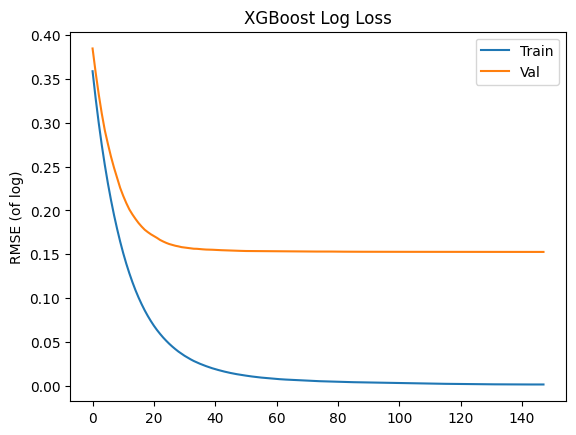

In [69]:
# Use XGBoost Library to fit it
X_train_preproc = preproc.fit_transform(X_train, y_train_log)
X_eval_preproc = preproc.transform(X_eval)

model_xgb_early_stopping.fit(
    X_train_preproc,
    y_train_log,
    verbose=False,
    eval_set=[(X_train_preproc, y_train_log), (X_eval_preproc, y_eval_log)],
)

# Retrieve performance metrics
results = model_xgb_early_stopping.evals_result()
epochs = len(results['validation_0']["rmse"])
x_axis = range(0, epochs)

# Plot RMSLE loss
fig, ax = plt.subplots()

ax.plot(x_axis, results['validation_0']['rmse'], label='Train')
ax.plot(x_axis, results['validation_1']['rmse'], label='Val')
ax.legend(); plt.ylabel('RMSE (of log)'); plt.title('XGBoost Log Loss')


In [70]:
print("Best Validation Score", min(results['validation_1']['rmse']))

Best Validation Score 0.15262311257551747


#### (H) stacking 


In [71]:
gboost = GradientBoostingRegressor(n_estimators=100)
ridge = Ridge()
svm = SVR(C=1, epsilon=0.05)
adaboost = AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=None))

model_stacking = StackingRegressor(
    estimators=[("gboost", gboost), ("adaboost", adaboost), ("ridge",ridge), ("svm_rbf", svm)],
    final_estimator=LinearRegression(),
    cv=5,
    n_jobs=-1
)

pipe_stacking = make_pipeline(preproc, model_stacking, memory=cachedir)

score_stacking_regressor = cross_val_score(pipe_stacking, X, y_log, cv=5, scoring=rmse, n_jobs=-1).mean()


/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4, 5, 21] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6, 14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4, 5, 6, 9, 14, 16, 17] during transf

In [72]:
print(f'The score of stacking with stacking regressor is : {score_stacking_regressor} ')

The score of stacking with stacking regressor is : 0.12282989043891204 


In [74]:
gboost = GradientBoostingRegressor(n_estimators=100)
ridge = Ridge()
svm = SVR(C=1, epsilon=0.05)
adaboost = AdaBoostRegressor(estimator=DecisionTreeRegressor(max_depth=None))


model_voting= VotingRegressor(
    estimators = [("gboost", gboost), ("adaboost", adaboost), ("ridge", ridge), ("svm_rbf", svm)],
    weights = [1, 1, 1, 1], # to equally weight the models
    n_jobs=-1
)

pipe_voting = make_pipeline(preproc, model_voting, memory=cachedir)

score_stacking_voting= cross_val_score(pipe_voting, X, y_log, cv=5, scoring=rmse, n_jobs=-1).mean()


/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4, 5, 21] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [6, 14] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [4] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/Users/gechen/.pyenv/versions/3.12.9/envs/lewagon/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [16] during transform. These unknown c

In [75]:
print(f'The score of stacking with StackingRegressor is : {score_stacking_voting}')

The score of stacking with StackingRegressor is : 0.12605962287528985


# 🏅FINAL DELIVERY

It is time to discover how well your model generalizes. Use your best-performing pipeline to generate final predictions for the holdout set and export them for stakeholders.

In [31]:
X_test = pd.read_csv("https://wagon-public-datasets.s3.amazonaws.com/houses_test_raw.csv")

X_test_ids = X_test['Id'] # Keep ids
X_test = X_test.drop(columns=['Id'])
X_test

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,Inside,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,Inside,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1454,160,RM,21.0,1936,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,6,2006,WD,Normal
1455,160,RM,21.0,1894,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,4,2006,WD,Abnorml
1456,20,RL,160.0,20000,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,NaN,NaN,0,9,2006,WD,Abnorml
1457,85,RL,62.0,10441,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,0,NaN,MnPrv,Shed,700,7,2006,WD,Normal


If you ran the optional cyclical feature treatment in 2.1, you will need to run the following cell to add the extra columns before you feed X_test into your pipeline.

In [32]:
if 'months_in_a_year' in locals():
    # months_in_a_year is defined, so we need to add the cyclical features
    X_test['sin_MoSold'] = np.sin(2 * np.pi * (X_test.MoSold - 1) / months_in_a_year)
    X_test['cos_MoSold'] = np.cos(2 * np.pi * (X_test.MoSold - 1) / months_in_a_year)

    X_test.drop(columns=['MoSold'], inplace=True)

👉 Predict using your best estimator, and store the results in `predictions`.

In [78]:
scores = [score_xgb,score_svr,score_knn,score_gb,score_random_forest,\
    score_ridge_log,score_stacking_voting,score_stacking_regressor]
scores

[0.1510105713569211,
 0.1475373280209901,
 0.20260844776848835,
 0.12953049166749203,
 0.1623280263195644,
 0.1482542905305449,
 0.12605962287528985,
 0.12282989043891204]

In [79]:
pipe_stacking.fit(X, y_log)

predictions_log = pipe_stacking.predict(X_test)
predictions = np.exp(predictions_log)

In [80]:
# Create a DataFrame in the correct format
results = pd.concat([X_test_ids, pd.Series(predictions, name="SalePrice")], axis=1)
results

,Id,SalePrice
0,1461,117800.613176
1,1462,159397.897593
2,1463,182731.693027
3,1464,189705.221340
4,1465,188652.801613
...,...,...
1454,2915,78951.657342
1455,2916,83061.857798
1456,2917,173846.989934
1457,2918,115756.144887


In [81]:
# Export to csv file
results.to_csv("/Users/gechen/Projects/HousePricePrediction/data/prediction_final.csv", header=True, index=False)

## 🚀 Model Export & Inference Readiness

The preprocessing pipeline and final model are exported as a single
deployable object, allowing consistent preprocessing during inference.

This mirrors how ML models are prepared for real-world deployment
(Streamlit app, API endpoint, batch prediction, etc.).


In [5]:
import pickle # Export Pipeline as pickle file

In [83]:
with open('/Users/gechen/Projects/HousePricePrediction/model/pipeline_stacking.pkl','wb') as file:
    pickle.dump(pipe_stacking,file)

In [29]:
model = pickle.load(open('/Users/gechen/Projects/HousePricePrediction/model/pipeline_stacking.pkl','rb'))

In [30]:
model.predict(X_test).shape

NameError: name 'X_test' is not defined

In [48]:
test_example = pd.read_csv('/Users/gechen/Projects/HousePricePrediction/data/test_api.csv')
test_ids = test_example['Id']
test_example = test_example.drop(columns=['Id'])
test_example['sin_MoSold'] = np.sin(2 * np.pi * (X_test.MoSold - 1) / 12)
test_example['cos_MoSold'] = np.cos(2 * np.pi * (X_test.MoSold - 1) / 12)
test_example.drop(columns=['MoSold'], inplace=True)
predict_log = model.predict(test_example)
predictions = np.exp(predict_log)
predictions[0]

117800.61317615218

In [53]:
pd.DataFrame(
    {
    'id':test_ids,
    'price': predictions[0]
    })

,id,price
0,1461,117800.613176


## 🧩 Model Explainability (SHAP)

To improve transparency and interpretability, SHAP values are used to:

- analyze **global feature importance**
- explain **individual predictions**
- verify that high-impact features (e.g., quality, living area, year built)
  influence prices in economically meaningful directions

This step demonstrates that the model is not a black box and supports
responsible ML practice.

In [168]:
import shap
shap.initjs()

In [ ]:
# Get all the feature name
all_feature_names = preproc_transformer.get_feature_names_out()
# get the portion of SelectPercentile save it to  mask
mask = preproc_selector.get_support()
# Get the the final feature name
feature_names = all_feature_names[mask]

clean_names = [i.split("__")[1] for i in feature_names]


 94%|=================== | 1031/1095 [00:12<00:00]       

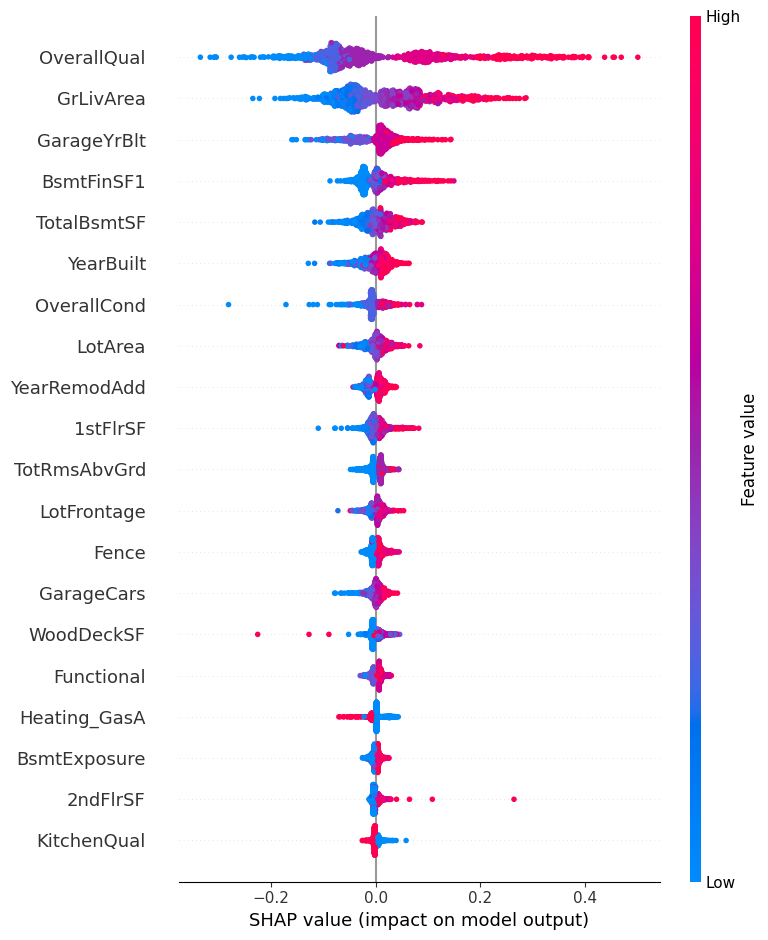

In [202]:
explainer = shap.Explainer(model_xgb_early_stopping, X_train_preproc)
shap_values = explainer(X_train_preproc)

shap.summary_plot(
    shap_values,
    X_train_preproc,
    feature_names=clean_names
)

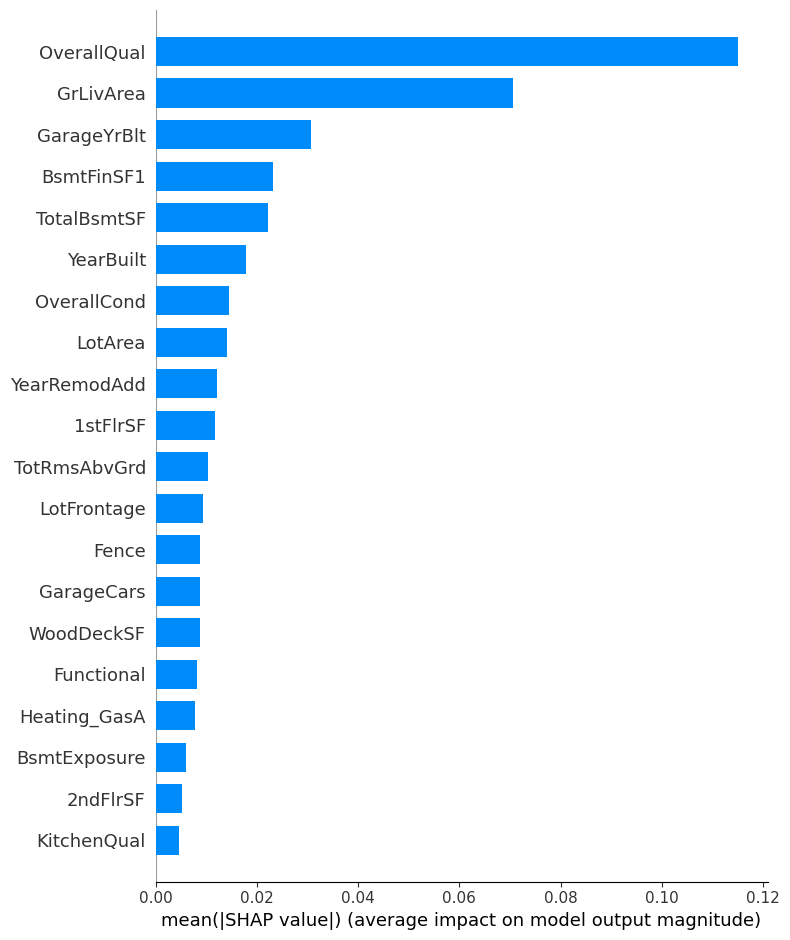

In [203]:
shap.summary_plot(
    shap_values,
    X_train_preproc,
    feature_names=clean_names,
    plot_type="bar"
)

## 📊 Evaluation Summary & Interpretation

The final model demonstrates a significant improvement over the baseline.
Performance gains primarily come from:

- structured preprocessing
- feature selection
- ensemble / stacking strategies

Beyond metrics, we interpret model behavior to ensure that the learned
patterns are consistent with real-world housing economics.